In [41]:
from bs4 import BeautifulSoup
import requests
import spacy

from chromadb.utils import embedding_functions
import chromadb
import pandas as pd

import nltk
nltk.download('stopwords')
stops_ptbr = nltk.corpus.stopwords.words('portuguese')
stops_ptbr.append('cf')

import os

from unidecode import unidecode

from langchain_chroma import Chroma
from langchain_community.embeddings.spacy_embeddings import SpacyEmbeddings
from langchain_core.embeddings import Embeddings


from langchain_core.documents import Document


[nltk_data] Downloading package stopwords to /home/jeff/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df_scrapper = pd.read_csv("./files/scrapper_dados_catecismo_lg.csv")

In [42]:

nlp_sm = spacy.load("pt_core_news_lg")

class SpacyEmbeddingsCustom(Embeddings):
    def embed_documents(self, texts):
        embeddings = []
        for text in texts:
            doc = nlp_sm(text)
            embeddings.append(doc.vector)
        return embeddings
    
    def embed_query(self, text):
        doc = nlp_sm(text)
        return doc.vector

In [8]:
TOKEN_OPENAI = os.getenv("OPENAI_KEY")

In [28]:
# Versão corrigida da sua função
def format_documents(df):
    documents = []
    for index, row in df.iterrows():
        text = row['text']
        page = row['link']
        

        if not isinstance(text, str) or not text.strip():
            continue 
            
        index_num = page.split('/')[-1].replace('_po.html','').split("_")[-1]

        doc = Document(
            page_content=text, 
            metadata={"source": "catecismo", "page": page, "index": index_num}
        )
        documents.append(doc)
    return documents

In [47]:
def create_bancos(documents):
    embedding_function = SpacyEmbeddingsCustom()
    db = Chroma(
        collection_name='collection_catecismo_lg',
        embedding_function=embedding_function,
        persist_directory='./databases/db_catecismo'
    )
    
    # Verificar se o banco já contém documentos
    existing_docs = db.get()  # Obtém os documentos armazenados
    
    uuids = ["item_"+str(i) for i in range(len(documents))]
    
    if existing_docs and len(existing_docs['ids']) > 0:
        return "Banco já criado", db
    else:
        # o chromadb não permite adiciona mais do que 5mil documentos de uma vez é necessário dividir em lotes
        batch_size = 1000
        for i in range(0, len(documents), batch_size):
            batch_documents = documents[i:i + batch_size]
            batch_uuids = uuids[i:i + batch_size]
            print("--> Adicionando lote de documentos:", i, "a", i + len(batch_documents))
            db.add_documents(documents=batch_documents, ids=batch_uuids)
        #db.add_documents(documents=documents, ids=uuids)
         # Certifique-se de persistir os dados
        return "Banco criado com sucesso", db


In [48]:
documents = format_documents(df_scrapper)

In [49]:
create_bancos(documents)

--> Adicionando lote de documentos: 0 a 1000
--> Adicionando lote de documentos: 1000 a 2000
--> Adicionando lote de documentos: 2000 a 3000
--> Adicionando lote de documentos: 3000 a 4000
--> Adicionando lote de documentos: 4000 a 5000
--> Adicionando lote de documentos: 5000 a 6000
--> Adicionando lote de documentos: 6000 a 7000
--> Adicionando lote de documentos: 7000 a 8000
--> Adicionando lote de documentos: 8000 a 8669


('Banco criado com sucesso',
 <langchain_chroma.vectorstores.Chroma at 0x7faf61d24290>)

In [ ]:
def get_sentences_similari(pergunta, nk = 20):
     collection = 'collection_catecismo_lg' 
     path_db = './databases/db_catecismo'
     embedding_function = SpacyEmbeddingsCustom()
     
     db = Chroma(collection_name= collection, 
          embedding_function= embedding_function, 
          persist_directory = path_db)
     
     pergunta = unidecode(pergunta.lower())
     print(pergunta)
     sentencas_similar = db.similarity_search(query = pergunta, k = nk)
     metadatas = [se.metadata for se in sentencas_similar]
     sentencas = [se.page_content for se in sentencas_similar]

     
     return sentencas, metadatas

In [58]:
get_sentences_similari("O que é a fé?", 10)

o que e a fe?


(['  Não desejarás a mulher do próximo, nem o seu servo nem a sua serva,o seu boi ou o seu jumento, nem nada que lhe pertença.',
  '  Não desejarás a mulher do próximo, nem o seu servo nem a sua serva,o seu boi ou o seu jumento, nem nada que lhe pertença.',
  "2748. Nesta oração pascal, sacrificial, tudo está «recapitulado» n'Ele (39): Deus e o mundo, o Verbo e a carne, a vida eterna e o tempo, o amor que se entrega e o pecado que o atraiçoa, os discípulos presentes e os que n'Ele hão-de crer pela palavra deles, a humilhação e a glória. É a Oração da Unidade.",
  '1411.  Só os sacerdotes validamente ordenados podem presidir à Eucaristia e consagrar o pão e o vinho, para que se tornem o corpo e o sangue do Senhor:',
  "2134. O primeiro mandamento chama o homem a crer em Deus, a esperar n'Ele e a amá-Lo sobre todas as coisas.",
  '68. Por amor, Deus revelou-Se e deu-Se ao homem. Dá assim uma resposta definitiva e superabundante às questões que o homem se põe a si próprio sobre o sentido 

In [14]:
from langchain_core.documents import Document
from uuid import uuid4

In [15]:
def clear_texts(list_textos):
    if isinstance(list_textos, list):
        for i, text in enumerate(list_textos):
            words = unidecode(text['texto']).lower().split()
            
            #words = ''.join(char for word in words for char in word if char not in """.,!?;:"\'>""")

            sent = ' '.join([word for word in words if word not in stops_ptbr])
            sent = ''.join(char for word in sent for char in word if char not in """.,!?;:"\'<>)(""")

            list_textos[i]['texto_clear'] = sent

        return list_textos
    


In [16]:
def set_remove_number_text(text_list):

    sentencas = []

    for i, sent in enumerate(text_list):
        #print(sent)
        new_sent = []

        for word in sent['texto_clear'].split():
            #print(word)
            if not word.isnumeric():
                new_sent.append(word)

        new_sent = ' '.join(new_sent)
        sentencas.append(new_sent)
        text_list[i]['text_clear_sm_nu'] = new_sent

    return sentencas, text_list


In [17]:
import pandas as pd

In [18]:
def get_number_artigo(item):
    text = item['texto_clear']
    number = text.split()[0].isnumeric()
    if text.split()[0].isnumeric():
        return text.split()[0]
    else:
        artigo = item['link'].split('_')[-2:][0]
        return artigo

In [19]:
list_texts = clear_texts(list_texts)




In [20]:
for i, sent in enumerate(list_texts):
    no_artigo = get_number_artigo(sent)
    sent['no_artigo'] = no_artigo

    list_texts[i] = sent



In [21]:
df_textos = pd.DataFrame(list_texts)
df_textos['size_sentences'] = df_textos['texto_clear'].apply(lambda x: len(x.split()))

df_textos.head()


,texto,link,texto_clear,no_artigo,size_sentences
0,Cannot serve request to /archive/cathechism_po...,https://www.vatican.va/archive/cathechism_po/i...,cannot serve request to /archive/cathechism_po...,po/index,8
1,SANTO PADRE,https://www.vatican.va/archive/cathechism_po/i...,santo padre,new/../../ccc/index,2
2,CÚRIA ROMANA,https://www.vatican.va/archive/cathechism_po/i...,curia romana,new/../../ccc/index,2
3,SERVIÇOS INFORMAÇÃO,https://www.vatican.va/archive/cathechism_po/i...,servicos informacao,new/../../ccc/index,2
4,CIDADE DO VATICANO,https://www.vatican.va/archive/cathechism_po/i...,cidade vaticano,new/../../ccc/index,2


In [22]:
def create_docs(list_dics):
    list_docs = []
    for dic in list_dics:
        new_dic = dic.copy()
        text_clear = new_dic['texto_clear']
        new_dic.pop('texto_clear')
        doc = Document(page_content=text_clear , 
                metadata = new_dic)
        
        list_docs.append(doc)

    return list_docs 

    

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation, MiniBatchNMF

def set_remove_number_text(text_list):

    sentencas = []

    for i, sent in enumerate(text_list):
        #print(sent)
        new_sent = []

        for word in sent['texto_clear'].split():
            #print(word)
            if not word.isnumeric():
                new_sent.append(word)

        new_sent = ' '.join(new_sent)
        sentencas.append(new_sent)
        text_list[i]['text_clear_sm_nu'] = new_sent

    return sentencas, text_list

sentencas, list_texts = set_remove_number_text(list_texts)

tfidf = TfidfVectorizer().fit(sentencas)

matriz_tfidf = tfidf.transform(sentencas)
tfidf_feature_names = tfidf.get_feature_names_out()

nmf_topics = NMF(
    n_components=10,
    random_state=1,
    init="nndsvda",
    beta_loss="kullback-leibler",
    solver="mu",
    max_iter=1000,
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=0.5,
).fit(matriz_tfidf)

In [24]:
import matplotlib.pyplot as plt

def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

            


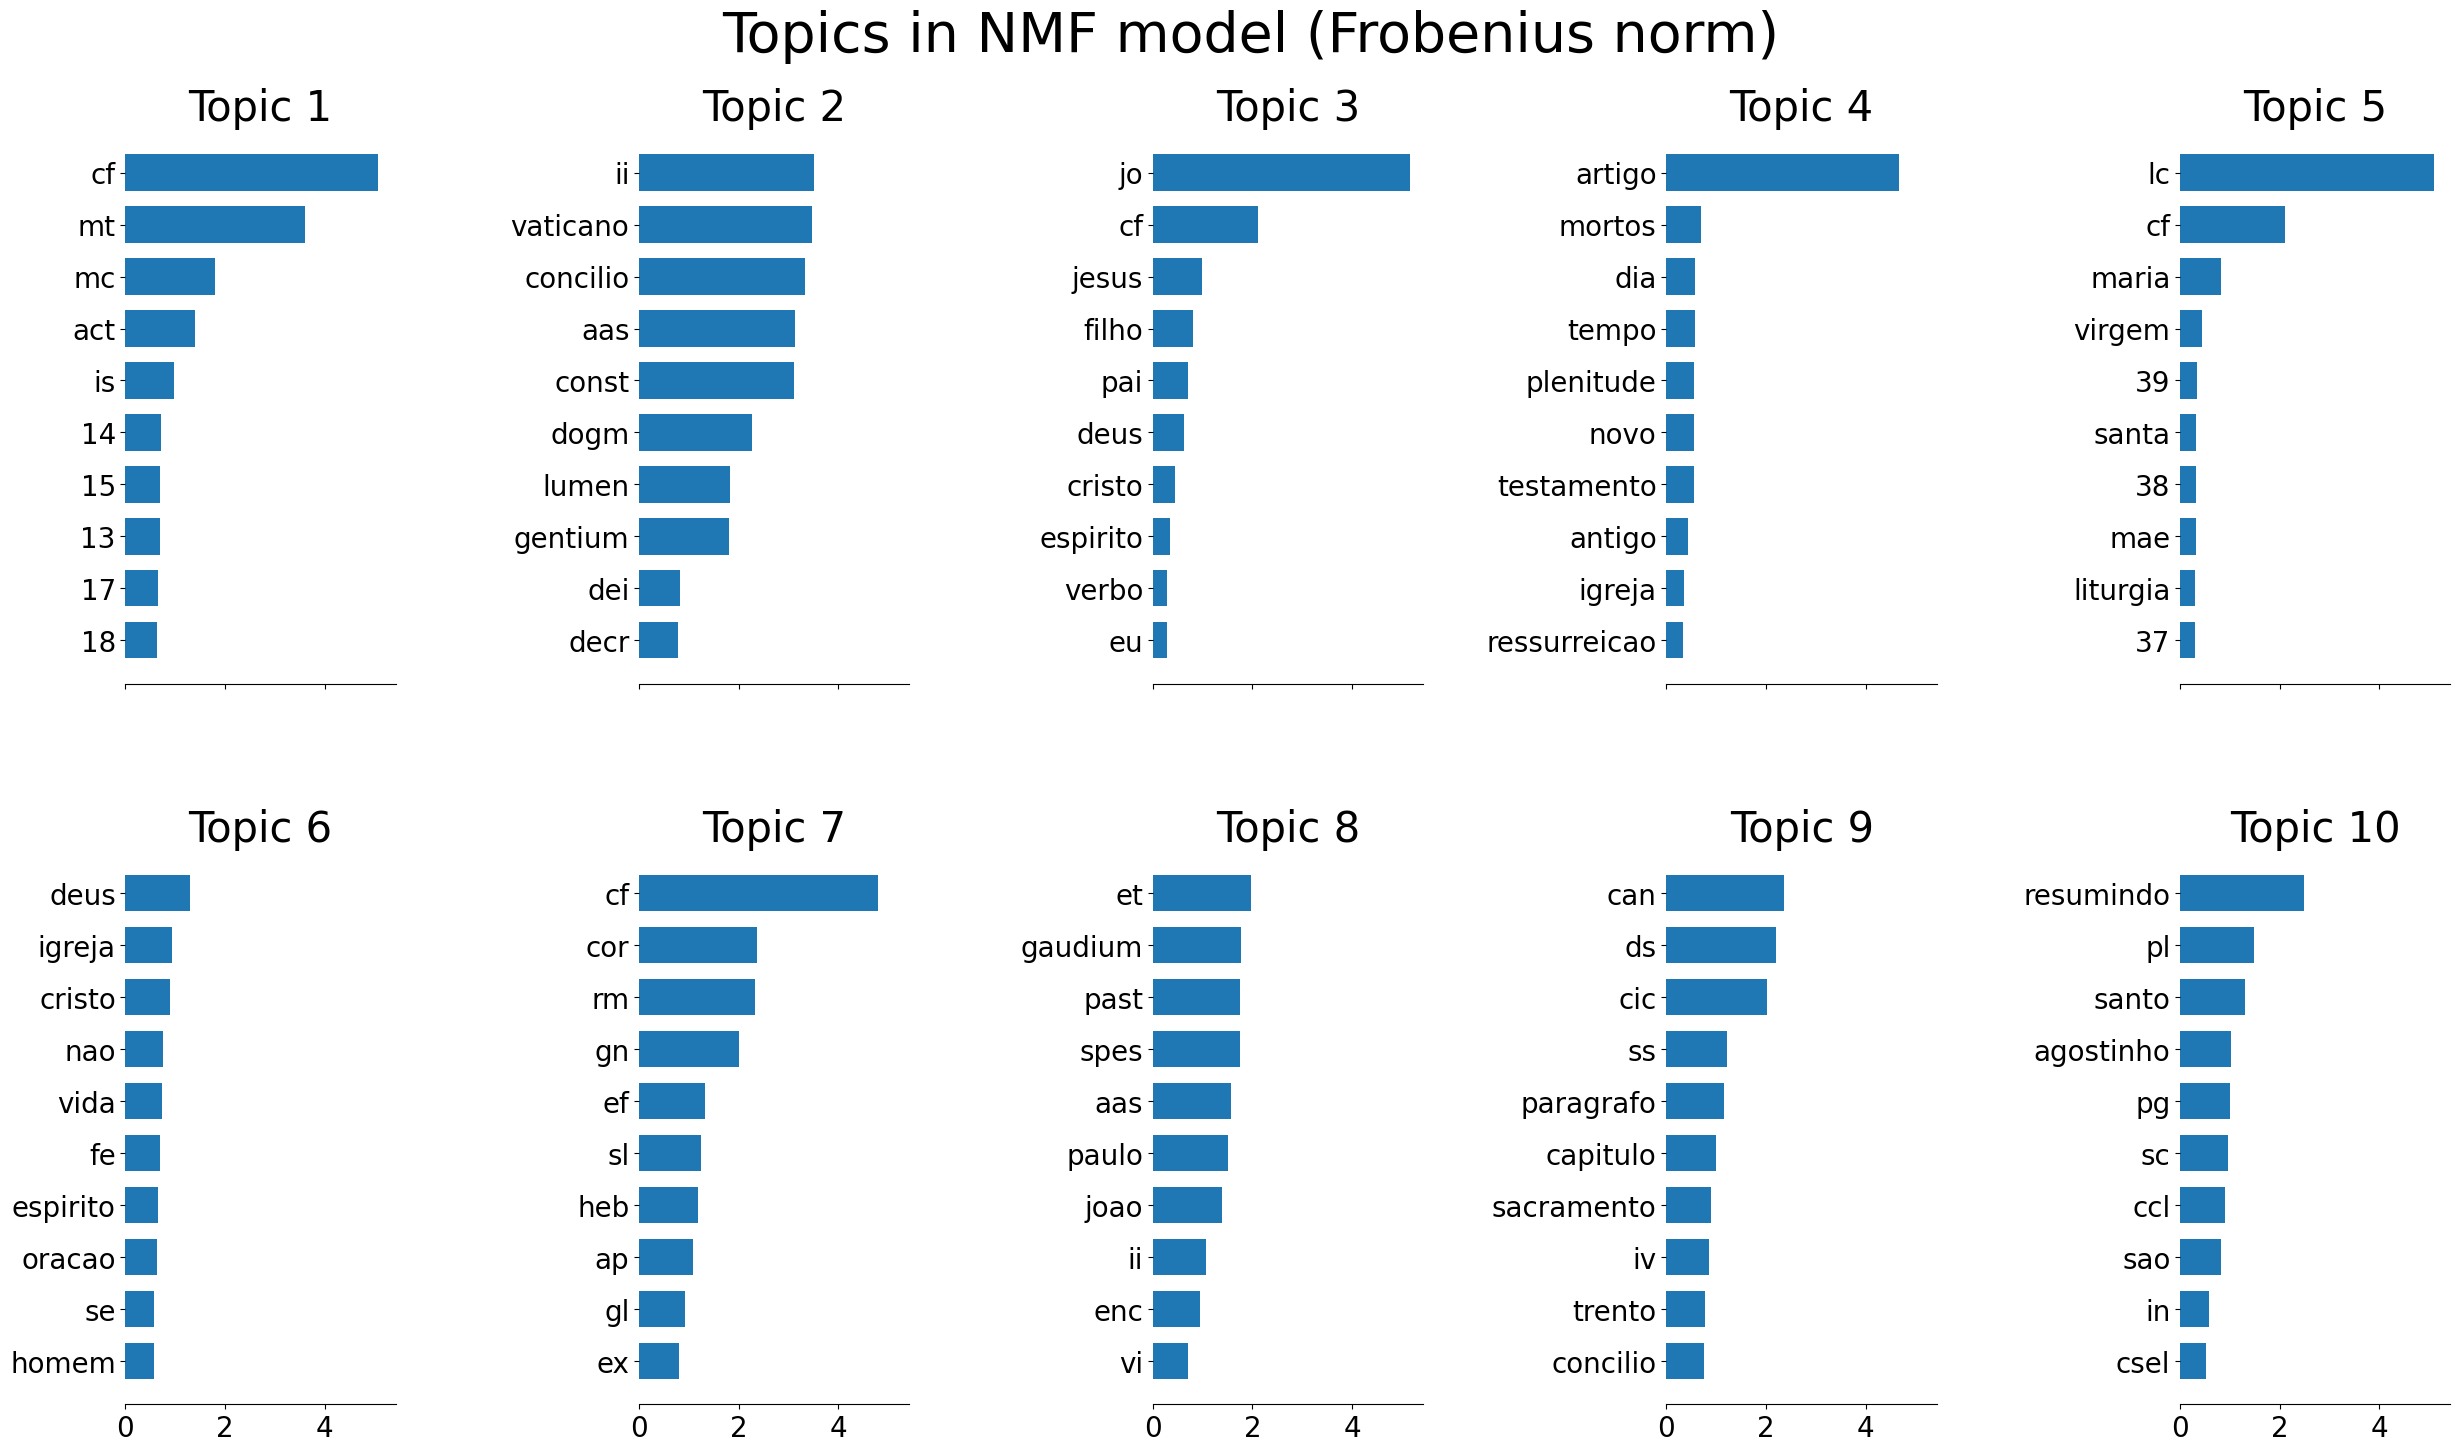

In [25]:
plot_top_words(
    nmf_topics, tfidf_feature_names, 10, "Topics in NMF model (Frobenius norm)"
)

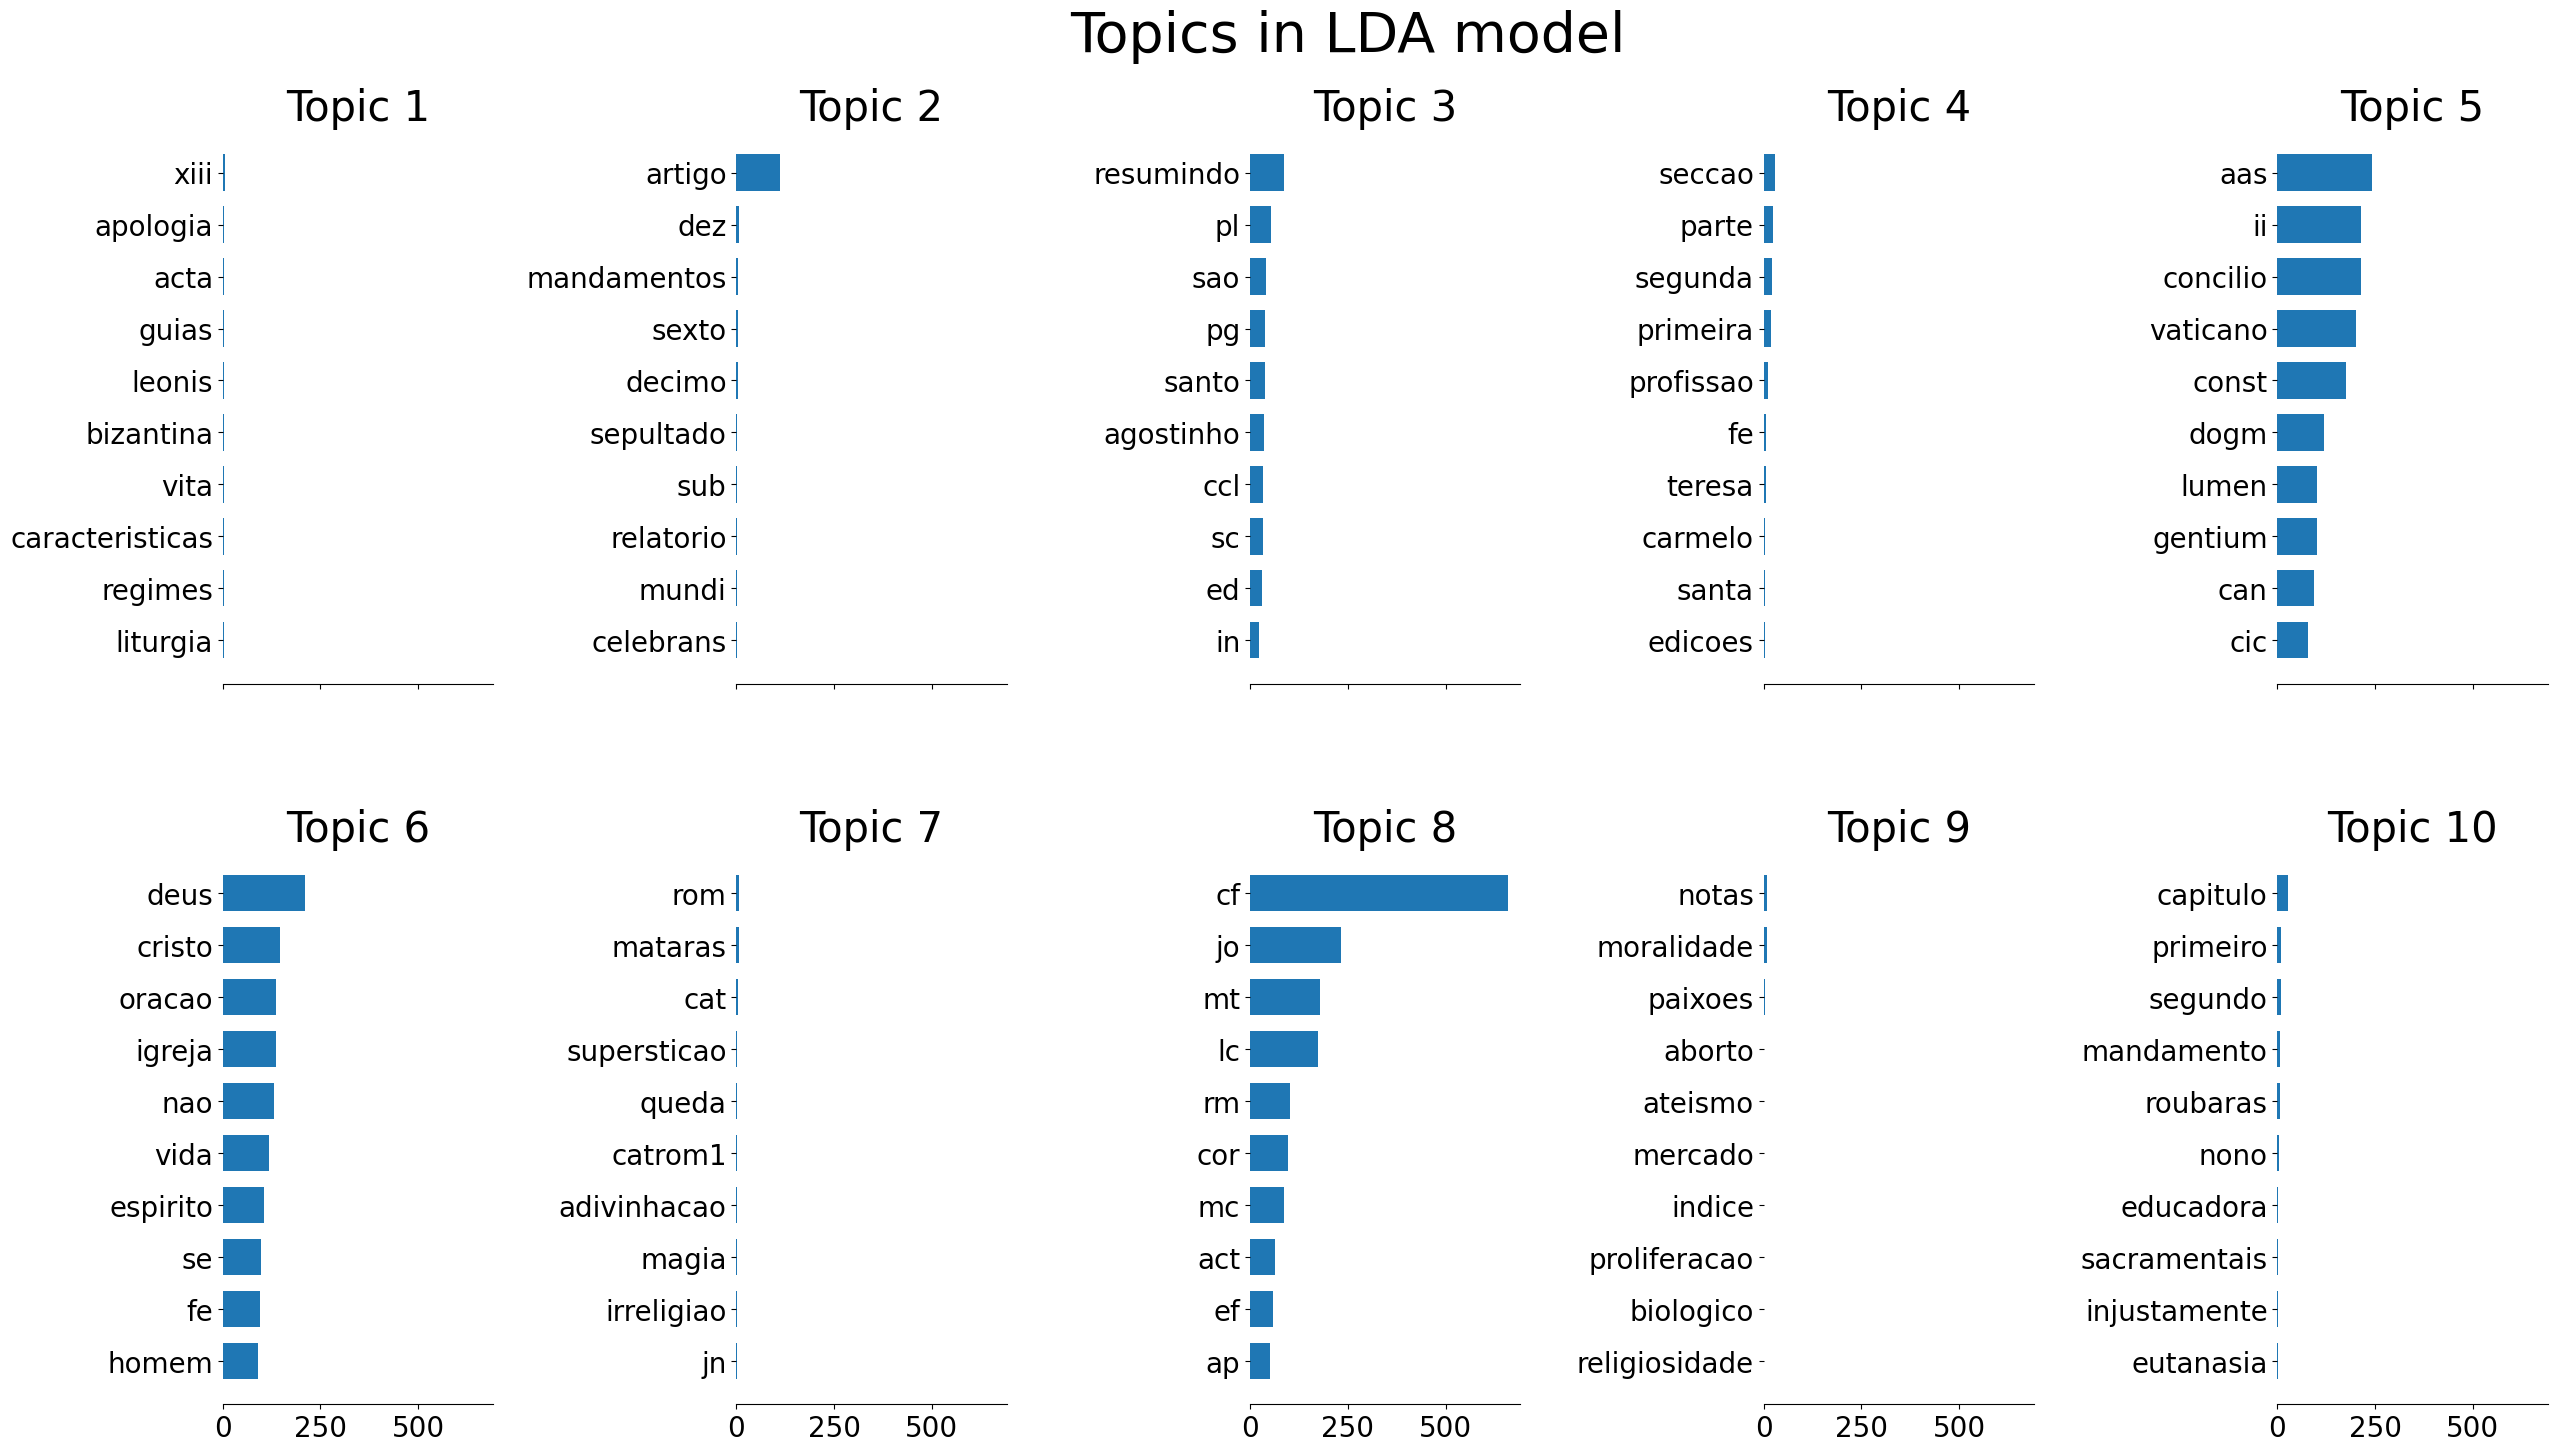

In [26]:
lda = LatentDirichletAllocation(
    n_components=10,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)

lda.fit(matriz_tfidf)

plot_top_words(
    lda, tfidf_feature_names, 10, "Topics in LDA model"
)

In [27]:
tfidf_df = pd.DataFrame(matriz_tfidf.toarray(), columns=tfidf_feature_names)
tfidf_df = tfidf_df.melt()

tfidf_df = tfidf_df.groupby(['variable'], as_index=False).agg({'value':'sum'})
tfidf_df = tfidf_df.sort_values('value', ascending=False)
tfidf_df[['value']].describe(percentiles=[.25, .5, .75, .85, .90, .95, .99])

,value
count,14658.000000
mean,1.999379
std,10.380299
min,0.096078
25%,0.222022
50%,0.421779
75%,1.093183
85%,2.054723
90%,3.233040
95%,6.882894


In [28]:
documents = create_docs(list_texts)
uuids = [str(i+1) for i, _ in enumerate(list_texts)]


In [29]:
mensagem, db = create_bancos(documents, uuids)
print(mensagem)

Banco já criado


In [30]:
results = db.similarity_search(query='santissima trindade', k = 20)
results[0].metadata

{'link': 'https://www.vatican.va/archive/cathechism_po/index_new/p1s2cap3_683-1065_po.html',
 'no_artigo': '1031',
 'text_clear_sm_nu': 'igreja chama purgatorio purificacao final eleitos absolutamente distinta castigo condenados igreja formulou doutrina fe relativamente purgatorio sobretudo concilios florenca trento tradicao igreja referindo-se certos textos escritura fala dum fogo purificador',
 'texto': '1031. A Igreja chama Purgatório a esta purificação final dos eleitos, que é absolutamente distinta do castigo dos condenados. A Igreja formulou a doutrina da fé relativamente ao Purgatório sobretudo nos concílios de Florença (622) e de Trento (623). A Tradição da Igreja, referindo-se a certos textos da Escritura (624) fala dum fogo purificador:'}

In [31]:
get_sentences_similari('o que é indulgência plenaria')

o que e indulgencia plenaria


[{'link': 'https://www.vatican.va/archive/cathechism_po/index_new/p3s2cap2_2196-2557_po.html',
  'no_artigo': '2392',
  'text_clear_sm_nu': 'o amor vocacao fundamental inata todo humano',
  'texto': '2392. «O amor é a vocação fundamental e inata de todo o ser humano» (145).'},
 {'link': 'https://www.vatican.va/archive/cathechism_po/index_new/p3s1cap1_1699-1876_po.html',
  'no_artigo': '1699-1876',
  'text_clear_sm_nu': 'o homem racional e isso semelhante deus criado livre senhor actos',
  'texto': '«O homem é racional e, por isso, semelhante a Deus, criado livre e senhor dos seus actos» (30).'},
 {'link': 'https://www.vatican.va/archive/cathechism_po/index_new/p4s1cap2_2650-2696_po.html',
  'no_artigo': '2650-2696',
  'text_clear_sm_nu': 'o espirito verdadeiramente lugar santos santo e espirito lugar proprio pois oferece habitar deus chamado templo35',
  'texto': '«O Espírito é verdadeiramente o lugar dos santos. E o santo é, para o Espírito, um lugar próprio, pois se oferece para habi

In [32]:
from openai import OpenAI


In [34]:
def get_resposta_chat(pergunta):
    pergunta = clear_texts([{'texto':pergunta}])[0]['texto_clear']
    #print(pergunta)
    sentencas = get_sentences_similari(pergunta)


    prompt_final = [{"role": "system", "content": """Voce é um assistente que presta informações referentes a igreja católica apóstolica romana e deve 
           responder obrigatoriamente com base nas sentenças fornecidas. Monte uma resposta proxima a linguagem humana à pergunta com base obrigatoriamente nas sentencas entre aspas triplas.
        # INSTRUÇÕES:
            - Caso não exista nenhuma sentenca que seja coerente com a pergunta voce deverá responder: "Não foi possível encontrar essa questão no catecismo da igreja católica"
            - retorne o Link como referência
        
        Exemplo:
            PERGUNTA: Qual é o oitavo mandamento
            SENTENCAS: "«Não levantarás falso testemunho contra o teu próximo» (Ex 20, 16). |
            «Foi dito aos antigos: "Não faltarás ao que tiveres jurado; hás-de cumprir os teus juramentos para com o Senhor"» (Mt 5, 33). |
            2464. O oitavo mandamento proíbe falsificar a verdade nas relações com outrem. Esta prescrição moral decorre da vocação do povo santo para ser 
            testemunha do seu Deus, que é e que quer a verdade. As ofensas à verdade exprimem, por palavras ou por actos, a recusa em 
            empenhar-se na rectidão moral: são infidelidades graves para com Deus e, nesse sentido, minam os alicerces da Aliança.
                
            Catecismo da Igreja - IA:O oitavo mandamento é, Não levantarás falso testemunho contra o teu próximo.
            fonte: www.exemplo.com.br """},

        { "role":"user", "content": f"""
        '''PERGUNTA: {pergunta}'''
        '''SENTENCAS: {sentencas}'''
        """}]
    
    client = OpenAI(api_key=TOKEN_OPENAI)
    completion = client.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=prompt_final
    )

    resposta = completion.choices[0].message.content

    return "Catecismo da Igreja - IA: "+ resposta

In [49]:

pergunta = 'quem é Deus?'


print(get_resposta_chat(pergunta))

deus
Catecismo da Igreja - IA: "«Creio em um só Deus» (Símbolo Niceno-Constantinopolitano). |
«Em muitas passagens, a Sagrada Escritura atribui ao coração as decisões deliberadas. Para crer em Deus, reconhecer e acolher o amor do seu coração é o princípio da nossa ascese» (Catecismo da Igreja Católica, 143)."

A informação sobre Deus pode ser encontrada no catecismo da igreja católica através do link: [DEUS É A VERDADE](https://www.vatican.va/archive/cathechism_po/index_new/p1s2c1_198-421_po.html)
